# **Understanding FEMA Hazard Mitigation Projects**

Jessica Odishoo, Jingchuan Tang,  Alex Wang

# Introduction

Natural disasters have caused significant losses to various cities in the United States. Take New York as an example: in October 2012, 52 people died directly due to injuries in Superstorm Sandy (Environment & Health Data Portal, 2024). Meanwhile, more deaths indirectly occurred with the storm’s damage impact (especially for the elderly and people living in coastal areas). Low-lying areas and basement apartments were severely damaged by significant inland flooding across a broader area of the city. Over the coming decades, sea levels in NYC are estimated to rise by 45 inches in the 2080s and 177 inches by 2150 (New York City Panel on Climate Change, 2024). Based on notable disaster losses, these projections reveal the urgency of preventing future natural disasters.

Fortunately, the Federal Emergency Management Agency (FEMA) has been promoting Hazard Mitigation Assistance (HMA) programs for a long while. Distributing funds is one of the most useful methods for establishing disaster-response measures on the government’s side. Considering environmental justice (with limited disaster mitigation funds and uneven distribution of disaster risks), this study aims to explore the correlation among HMA funding allocation, types of funded projects, and regions. In terms of data selection, this project used HMA’s grant application data from 2007 onward to focus on the cost-benefit outcomes of different disaster types and states. Choosing relatively recent data helps this study avoid comparability issues caused by early systematic data deficiencies and provides sufficient financial and geographic information for the samples. These samples served as key variables in the regression analysis, including project amounts, benefit-cost ratios (BCR), net benefit values (NVB), and disaster types. Firstly, this study employs descriptive statistics and visualization to illustrate the regional distribution of cost-benefit ratios and application scales. It visualizes a bar graph of net benefit values by region, statistics tables of applications and project numbers by disaster type and year, and a map showing the geographic distribution of projects’ cost difference by state. Additionally, the study creates a regression model of log cost differences to assess the extent to which observable factors can explain cost differences. Using this model, it identifies disaster types and states associated with significantly different cost patterns. Ultimately, the results of this project can help policymakers observe the effectiveness and equity of federal disaster mitigation expenditures.

# Setup

In [ ]:
# Import packages
import pandas as pd
import numpy as np
import requests
import json
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

# Data Import

A number of potential limitations exist in this data set. For example, we are only considering grant applications made after 2007. This is because grant applications from before 2007 came from numerous data sources, each with different ways of measuring our variables of interest, potentially introducing exogenous error. Although the data set after 2007 remains large, valuable insights from before 2007 may be excluded from our results.

Additionally, we observed several instances of human error in the data set, such as dates entered with obvious typos (e.g., 0220 instead of 2020). Although we made a good-faith effort to identify and correct such errors in our data cleaning process, other instances of human error may remain in the data. This would affect our results’ and findings’ validity.

More generally, FEMA’s Hazard Mitigation Assistance Program is only one of many grant programs available to mitigate the impact and severity of disasters. It’s possible that Hazard Mitigation Assistance Program applications include projects that are generally not representative of all disaster resilience projects, which would limit the applicability of our findings from our visualizations and analysis.

In [ ]:
# Function to call the FEMA API - works for multiple API versions and paths
def call_fema(path, version):
    api_url = f"https://www.fema.gov/api/open/v{version}/{path}"
    api_params = {
        "$allrecords": "true"
    }

    resp = requests.get(api_url, params=api_params)

    resp_json = resp.json()

    return pd.DataFrame(resp_json[path])

In [ ]:
# Call FEMA API for Hazard Mitigation Assistance Projects and put into dataframe
df = call_fema("HazardMitigationAssistanceProjects", "4")

In [ ]:
# Call FEMA API for list of disaster declarations and put into separate dataframe
disasters_df = call_fema("FemaWebDisasterDeclarations", "1")

# Data Processing

In [ ]:
# Left join the two dataframes we have together
# This means each Hazard Mitigation Assistance Program project will have the details of the associated disaster
# from the Disaster Declarations API endpoint
df = pd.merge(df, disasters_df, on='disasterNumber', how='left')

In [ ]:
# Validation: Check for duplication among (projectCounties, state, dateInitiallyApproved, projectAmount) which should be
# mostly unique
df.value_counts(subset=['projectCounties', 'state', 'dateInitiallyApproved', 'projectAmount']).sort_values(ascending=False)

projectCounties  state        dateInitiallyApproved     projectAmount
MARSHALL         Alabama      2007-04-20T00:00:00.000Z  26492.00         8
SEBASTIAN        Arkansas     2004-04-15T00:00:00.000Z  589294.00        8
MARION           Alabama      2012-11-09T00:00:00.000Z  18175.00         7
CLAYTON          Iowa         2008-02-04T00:00:00.000Z  5000.00          7
LAKE             Florida      2008-06-10T00:00:00.000Z  6546.00          6
                                                                        ..
YAUCO            Puerto Rico  2024-10-24T00:00:00.000Z  13000000.00      1
YAVAPAI          Arizona      2004-04-22T00:00:00.000Z  32027.00         1
                              2020-03-03T00:00:00.000Z  259792.67        1
                              2020-08-03T00:00:00.000Z  268000.00        1
YORK             Maine        2020-07-31T00:00:00.000Z  20000.00         1
Name: count, Length: 27685, dtype: int64

We observed one project that appeared duplicated based on the second criteria; however, upon further investigation, we chose to keep the project given their differing IDs and small number of similar instances.

In [ ]:
# Filter down to only Hazard Mitigation projects 2007 or later (as this is after the underlying data source was changed)
# and projects with positive obligation amounts, benefit cost ratios, and net value of benefits
df_new = df[df['programFy'] >= 2007][df['initialObligationAmount'] > 0][df['benefitCostRatio'] > 0][df['netValueBenefits']>0]

/tmp/ipython-input-3149992859.py:3: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

/tmp/ipython-input-3149992859.py:3: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

/tmp/ipython-input-3149992859.py:3: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



In [ ]:
# Find and correct dates with "00" in the year
# Possible symptom of typos when FEMA created the data set
dates_to_correct_initially_approved = df_new[df_new['dateInitiallyApproved'].str.slice(0, 2) == "00"]['dateInitiallyApproved']

for date_str in dates_to_correct_initially_approved:
    corrected_date_str = "20" + date_str[2:]
    df_new.loc[df_new['dateInitiallyApproved'] == date_str, 'dateInitiallyApproved'] = corrected_date_str

dates_to_correct_approved = df_new[df_new['dateApproved'].str.slice(0, 2) == "00"]['dateApproved']

for date_str in dates_to_correct_approved:
    corrected_date_str = "20" + date_str[2:]
    df_new.loc[df_new['dateApproved'] == date_str, 'dateApproved'] = corrected_date_str

dates_to_correct_closed_first_zeroes = df_new[df_new['dateClosed'].str.slice(0, 2) == "00"]['dateClosed']

for date_str in dates_to_correct_closed_first_zeroes:
    corrected_date_str = "20" + date_str[2:]
    df_new.loc[df_new['dateClosed'] == date_str, 'dateClosed'] = corrected_date_str

dates_to_correct_closed = df_new[df_new['dateClosed'].str.slice(2, 4) == "00"]['dateClosed']

for date_str in dates_to_correct_closed:
    corrected_date_str = "20" + date_str[0:2] + date_str[4:]
    df_new.loc[df_new['dateClosed'] == date_str, 'dateClosed'] = corrected_date_str

In [ ]:
# Replace particular unique instances of typo'd dates
df_new.replace("0204-07-02T00:00:00.000Z", "2024-07-02T00:00:00.000Z", inplace=True)
df_new.replace("0215-09-21T00:00:00.000Z", "2015-09-21T00:00:00.000Z", inplace=True)

# Fix data types
df_new['countyCode'] = pd.to_numeric(df_new['countyCode'], errors='coerce')
df_new['projectCounties'] = df_new['projectCounties'].str.split(';')

# remove \n characters from projectType
df_new['projectType'] = df_new['projectType'].str.replace('\n', '')
df_new['projectType'] = df_new['projectType'].str.split(';')
df_new['dateApproved'] = pd.to_datetime(df_new['dateApproved'])
df_new['dateInitiallyApproved'] = pd.to_datetime(df_new['dateInitiallyApproved'])
df_new['dateClosed'] = pd.to_datetime(df_new['dateClosed'])
df_new['initialObligationDate'] = pd.to_datetime(df_new['initialObligationDate'])


# generate status binary variable
df_new['statusBinary'] = df_new['status'].apply(lambda x: 1 if x in ['Approved', 'Awarded', 'Obligated', 'Completed', 'Closed'] else (-1 if x in ['Pending', 'Revision Requested', 'Withdrawn'] else 0))


/tmp/ipython-input-2643284695.py:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [ ]:
# Double check correct data types
df_new.dtypes

,0
projectIdentifier,object
programArea,object
programFy,int64
region_x,int64
state,object
stateNumberCode,object
county,object
countyCode,float64
disasterNumber,float64
projectCounties,object


In [ ]:
# Calculate cost difference - defined as project amount (cost of project) minus initial obligation amount (amount
# obligated by FEMA)
df_new['costDifference'] = df_new['projectAmount'] - df_new['initialObligationAmount']
df_new['costDifference']

,costDifference
0,94179.00
1,16977.00
2,11504.58
4,17267.00
5,4758223.00
...,...
54551,-10890.58
54554,21626.00
54558,-100200.00
54559,-591363.00


# Presentation

In [ ]:
# Simple descriptive stats
df_new.describe()

,programFy,region_x,countyCode,disasterNumber,projectAmount,initialObligationAmount,federalShareObligated,subrecipientAdminCostAmt,srmcObligatedAmt,recipientAdminCostAmt,costSharePercentage,benefitCostRatio,netValueBenefits,numberOfFinalProperties,numberOfProperties,region_y,statusBinary,costDifference
count,11692.000000,11692.000000,11541.000000,9512.000000,1.169200e+04,1.169200e+04,1.169100e+04,9512.000000,9.512000e+03,9512.000000,11692.000000,11692.000000,1.169200e+04,11692.000000,11692.000000,9512.000000,11692.000000,1.169200e+04
mean,2014.868115,4.919176,81.218265,3618.607443,1.862663e+06,7.355534e+05,9.161071e+05,268.690391,1.132665e+04,79.221413,0.772193,19.969709,1.094312e+07,5.038231,5.874701,4.850820,0.997691,1.127110e+06
std,4.654431,2.382517,91.686992,1179.736780,1.280417e+07,1.679785e+06,6.015210e+06,2602.093940,5.883941e+04,1052.512567,0.135451,1329.862873,3.181455e+08,70.861841,71.903700,2.359529,0.066008,1.243001e+07
min,2007.000000,1.000000,0.000000,1662.000000,0.000000e+00,3.379000e+02,0.000000e+00,-1288.000000,0.000000e+00,-4815.000000,0.000000,0.020000,1.000000e+00,0.000000,0.000000,1.000000,-1.000000,-1.558198e+07
25%,2011.000000,4.000000,23.000000,1971.000000,1.061442e+05,8.839833e+04,6.467762e+04,0.000000,0.000000e+00,0.000000,0.750000,1.220000,3.190455e+05,0.000000,0.000000,4.000000,1.000000,2.991750e+03
50%,2016.000000,4.000000,59.000000,4251.000000,3.712010e+05,2.426740e+05,2.305480e+05,0.000000,0.000000e+00,0.000000,0.750000,1.820000,1.124846e+06,0.000000,1.000000,4.000000,1.000000,5.996544e+04
75%,2019.000000,6.000000,109.000000,4429.000000,1.237640e+06,7.069073e+05,7.401101e+05,0.000000,0.000000e+00,0.000000,0.810000,3.712500,3.850000e+06,1.000000,1.000000,6.000000,1.000000,3.336437e+05
max,2025.000000,10.000000,830.000000,5487.000000,5.723770e+08,3.951850e+07,5.180288e+08,62983.000000,2.523483e+06,61360.000000,1.000000,143032.420000,3.386960e+10,6683.000000,6685.000000,10.000000,1.000000,5.672470e+08


One key finding from the descriptive statistics is that the financial variables, such as project amount, initial obligation, and federal share obligated, exhibit extreme right skew, with the median exceeding the mean. Moreover, one of our key variables, net value benefits, has significant outliers: the mean is only 10.9 million, while the maximum is 33.9 billion. Additionally, the benefit-cost ratio is important because it shows that a few major projects cause the BCR median to be only 1.82, with a maximum of 143,032. This also reveals a strong skewness that could distort our model.

In [ ]:
# Remove zero values from costDifference as we can't log a zero
df_new['costDifferenceNoZeroes'] = df_new['costDifference'].apply(lambda x: x+1 if x == 0 else x)
# Calculate log of cost difference
df_new['logCostDifference'] = np.log(df_new['costDifferenceNoZeroes'])
# Remove Biological disasters - since COVID is a disaster distinct from all others
df_regress = df_new[df_new['incidentType'] != 'Biological']

# Regress cost difference on incident (disaster type) and state name
model = smf.ols("logCostDifference ~ C(incidentType) + C(stateName)", data=df_regress).fit()

model.get_robustcov_results(cov_type="HC0").summary()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 72, but rank is 71



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      logCostDifference   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.241
Method:                 Least Squares   F-statistic:                     1723.
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        00:58:51   Log-Likelihood:                -14570.
No. Observations:                6856   AIC:                         2.929e+04
Df Residuals:                    6783   BIC:                         2.978e+04
Df Model:                          72                                         
Covariance Type:                  HC0                                         
==================================================================================================================
                                                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                                          9.1176      0.510     17.874      0.000       8.118      10.118
C(incidentType)[T.Dam/Levee Break]                 1.4996      0.939      1.597      0.110      -0.341       3.340
C(incidentType)[T.Earthquake]                     -0.0768      0.636     -0.121      0.904      -1.323       1.170
C(incidentType)[T.Fire]                            0.3370      0.517      0.652      0.515      -0.676       1.351
C(incidentType)[T.Flood]                           0.7340      0.507      1.447      0.148      -0.260       1.728
C(incidentType)[T.Freezing]                       -1.2016      1.051     -1.143      0.253      -3.262       0.859
C(incidentType)[T.Hurricane]                       0.9358      0.510      1.836      0.066      -0.063       1.935
C(incidentType)[T.Mud/Landslide]                   0.5044      0.595      0.847      0.397      -0.662       1.671
C(incidentType)[T.Other]                           0.4719      0.948      0.498      0.619      -1.386       2.330
C(incidentType)[T.Severe Ice Storm]               -0.4727      0.516     -0.915      0.360      -1.485       0.540
C(incidentType)[T.Severe Storm]                    0.1721      0.504      0.341      0.733      -0.816       1.160
C(incidentType)[T.Snowstorm]                       0.4522      0.528      0.856      0.392      -0.583       1.488
C(incidentType)[T.Tornado]                         0.1574      0.558      0.282      0.778      -0.937       1.251
C(incidentType)[T.Tropical Storm]                  0.0044      0.524      0.008      0.993      -1.023       1.031
C(incidentType)[T.Tsunami]                         0.8876      0.810      1.096      0.273      -0.700       2.475
C(incidentType)[T.Typhoon]                         6.2130      3.063      2.029      0.043       0.209      12.217
C(incidentType)[T.Volcanic Eruption]               1.7562      0.769      2.285      0.022       0.250       3.263
C(incidentType)[T.Winter Storm]                    0.2480      0.612      0.405      0.685      -0.951       1.447
C(stateName)[T.Alaska                        ]     2.1038      0.287      7.332      0.000       1.541       2.666
C(stateName)[T.American Samoa                ]     4.0516      0.730      5.550      0.000       2.621       5.483
C(stateName)[T.Arizona                       ]     1.6472      0.377      4.371      0.000       0.908       2.386
C(stateName)[T.Arkansas                      ]     2.8804      0.118     24.313      0.000       2.648       3.113
C(stateName)[T.California                    ]     3.6446      0.160     22.793      0.000       3.331       3.958
C(stateName)[T.Colorado                      ]     3.3744      0.352      9.586      0.000   

## Model fit:
The model explains approximately 24% of the variation in y.

## Regression Analysis:
logCostDifference effect is measured as %Δ=(e^β−1)×100

## Disaster Types
On average, Typhoons are associated with a 49,800% increase in cost difference relative to coastal storms, holding all else constant.

Volcanic Eruption: On average, Volcanic Eruptions are associated with a 175.64% increase in cost difference relative to coastal storms, holding all else constant.

## State-Level Effects
California:
On average, a disaster occurring in California is associated with a 3,700% increase in cost difference relative to a disaster occurring in Alabama, holding all else constant.


Florida:
On average, a disaster occurring in Florida is associated with a 730% increase in cost difference relative to a disaster occurring in Alabama, holding all else constant.


Puerto Rico:
On average, a disaster occurring in Puerto Rico is associated with a 3,370% increase in cost difference relative to a disaster occurring in Alabama, holding all else constant.


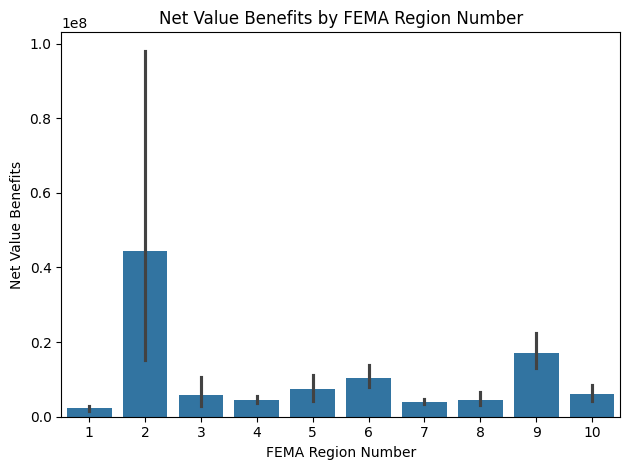

In [ ]:
# Plot net value of benefits by FEMA region number
sns.barplot(x='region_x', y='netValueBenefits', data=df_new)
plt.title('Net Value Benefits by FEMA Region Number')
plt.xlabel('FEMA Region Number')
plt.ylabel('Net Value Benefits')
plt.tight_layout()
plt.show()


## FEMA Region Definitions

* Region 1: Connecticut, Maine, Massachusetts, New Hampshire, Rhode Island, Vermont
* Region 2: New Jersey, New York, Puerto Rico, Virgin Islands
* Region 3: Delaware, Maryland, Pennsylvania, Virginia, District of Columbia, West Virginia
* Region 4: Alabama, Florida, Georgia, Kentucky, Mississippi, South Carolina, Tennessee
* Region 5: Illinois, Indiana, Michigan, Minnesota, Ohio, Wisconsin
* Region 6: Arkansas, Louisiana, New Mexico, Oklahoma, Texas
* Region 7: Iowa, Kansas, Missouri, Nebraska
* Region 8: Colorado, Montana, North Dakota, South Dakota, Utah, Wyoming
* Region 9: Arizona, California, Hawaii, Nevada, Guam, American Samoa, Northern Mariana Islands, Marshall Islands, Micronesia
* Region 10: Alaska, Idaho, Oregon, Washington

Taking advantage of the net value of benefits variable available in our data set, this visualization shows the geographic distribution of the Hazard Mitigation Assistance Program’s monetized impact. Regions with higher NVB values may face greater disaster risk than other regions, prompting them to seek more mitigation grants from FEMA.

Text(0.5, 1.0, 'Number of grant applications by disaster type')

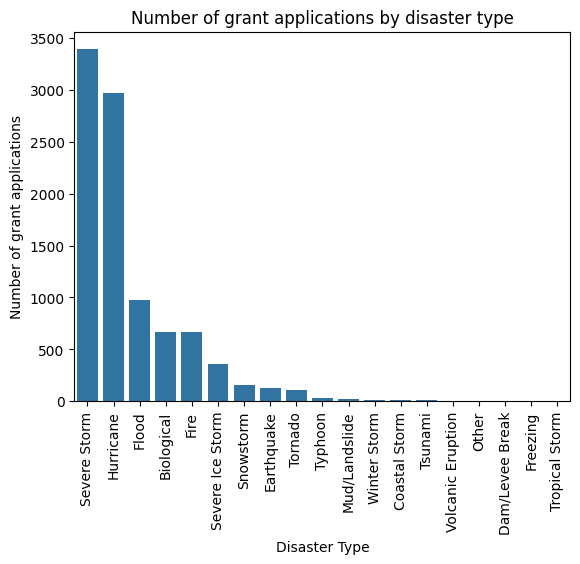

In [ ]:
# Create a copy of the existing df to manipulate for this visualization
df_grant_applications_viz = df_new[['incidentType']].copy()

# Aggregate grant application counts by incident type
df_grant_applications_viz = df_grant_applications_viz.groupby(['incidentType']).size().reset_index(name='count')
# Sort by count
df_grant_applications_viz = df_grant_applications_viz.sort_values('count', ascending=False)

# Render a bar graph plotting count against incident type
sns.barplot(x='incidentType', y='count', data=df_grant_applications_viz)
plt.xticks(rotation=90)
plt.ylabel("Number of grant applications")
plt.xlabel("Disaster Type")
plt.title('Number of grant applications by disaster type')

Taking grant applications as a proxy for the general desire to prepare for or mitigate disasters, this visualization shows the impact of each type of disaster; generally, more catastrophic types should prompt a stronger urge to mitigate them.

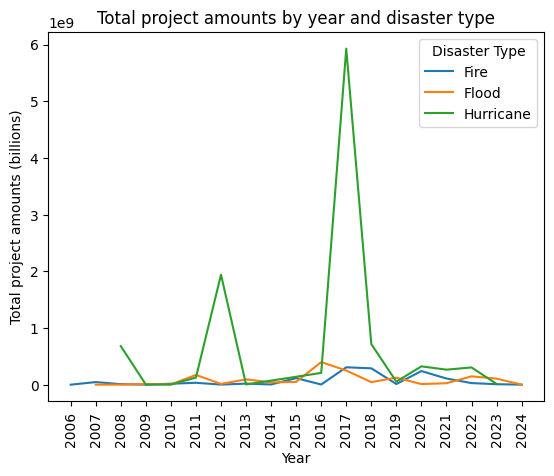

In [ ]:
# take only declarationDate, projectAmount, incidentType from df_new
df_total_proj_amts_viz = df_new[['declarationDate', 'projectAmount', 'incidentType', 'statusBinary']].copy()

# filter to incidentType of "Severe Storm", "Hurricane", "Flood", "Fire"
df_total_proj_amts_viz = df_total_proj_amts_viz[df_total_proj_amts_viz['incidentType'].isin(["Hurricane", "Flood", "Fire"])]

# cast declaratoinDate to datetime
df_total_proj_amts_viz['declarationDate'] = pd.to_datetime(df_total_proj_amts_viz['declarationDate'])

# generate column for year
df_total_proj_amts_viz['year'] = df_total_proj_amts_viz['declarationDate'].dt.year

# drop the cases where statusBinary == -1
df_total_proj_amts_viz = df_total_proj_amts_viz[df_total_proj_amts_viz['statusBinary'] != -1]

# sum projectAmount and group by disasterType and year
df_total_proj_amts_viz = df_total_proj_amts_viz.groupby(['incidentType', 'year']).agg({'projectAmount': 'sum'}).reset_index()

# plot projectAmount on y axis, year on x axis, and show incidentType using colored legend
sns.lineplot(data=df_total_proj_amts_viz, x='year', y='projectAmount', hue='incidentType')
plt.xticks(df_total_proj_amts_viz['year'].unique(), rotation=90)
plt.ylabel("Total project amounts (billions)")
plt.xlabel("Year")
plt.legend(title='Disaster Type')
plt.title('Total project amounts by year and disaster type')
plt.show()

Using aggregated project numbers from our dataset, this visualization shows the trend in the cost scale of disaster mitigation projects over time (mainly tracking three types of disasters: hurricanes, floods, and fires). Overall, the total cost of hurricane-related projects is higher than that of the other two types of disasters. In 2012 and 2017, there were clear peaks in project amounts related to hurricanes (roughly corresponding to periods of extreme hurricane activity). Funding levels for fire and flood-related projects are relatively stable, with only slight fluctuations in specific years.

In [ ]:
# Map

# Take the costDifference and stateNumberCode columns from df_new
map_df = df_new[['costDifference', 'logCostDifference', 'stateNumberCode']].copy()

# aggregate costDifference by stateNumberCode
map_df = map_df.groupby(['stateNumberCode']).agg({'logCostDifference': 'sum'}).reset_index()

# pull FIPS code to state abbrevation dataframe from github csv https://gist.github.com/dantonnoriega/bf1acd2290e15b91e6710b6fd3be0a53/raw/11d15233327c8080c9646c7e1f23052659db251d/us-state-ansi-fips.csv
fips_abbreviation_map = pd.read_csv('https://gist.github.com/dantonnoriega/bf1acd2290e15b91e6710b6fd3be0a53/raw/11d15233327c8080c9646c7e1f23052659db251d/us-state-ansi-fips.csv')

# Clean column names by stripping whitespace
fips_abbreviation_map.columns = fips_abbreviation_map.columns.str.strip()

# Ensure stateNumberCode is numeric for merging
map_df['stateNumberCode'] = pd.to_numeric(map_df['stateNumberCode'], errors='coerce')

# Merge map_df with fips_abbreviation_map to get the state abbreviations
map_df = pd.merge(map_df, fips_abbreviation_map[['st', 'stusps']], left_on='stateNumberCode', right_on='st', how='left')

# Rename the 'stusps' column to 'stateAbbreviation' and drop the redundant 'st' column
map_df.rename(columns={'stusps': 'stateAbbreviation'}, inplace=True)
map_df.drop(columns=['st'], inplace=True)

# Generate the choropleth map with a specified color scale
map_df = map_df.apply(lambda x: x.str.strip() if x.dtype == object else x)

map_df = map_df.dropna()

map = px.choropleth(color=map_df['logCostDifference'], locations=map_df['stateAbbreviation'], locationmode='USA-states', scope='usa', title='Cost Difference by State')

map.show()

Using the aggregated logarithmic cost differences of each state, the map visually presents the extent of cost differences among projects from a geographical perspective. States with warmer colors have higher logarithmic cost-difference values (HMA project cost differences are greater than those in states with cooler colors). Overall, only a few states show significant differences in project costs. This uneven distribution of cost differences also reflects regional disparities, with higher cost values mostly occurring in states with frequent or severe disasters. By highlighting areas with significant cost differences, this map provides a more intuitive visual supplement to the regression analysis results.

# Concluding Discussion

Generally, this study examines whether certain disaster types and specific regions systematically receive more funds from the HMA programs. Descriptive statistics reveal that financial variables such as project amount and NVB are highly right-skewed, with only a few projects having an NVB in the billions or a benefit-cost ratio exceeding 100,000. These relatively few large-scale investments significantly influenced the distribution of HMA project funds across regions and disaster types. Additionally, the regression analysis model in this study explains part of the variation in the logarithmic cost differences. The cost patterns of disaster types such as hurricanes and freezing are significantly different from the control category. Moreover, after controlling for disaster types, state indicators demonstrate notable regional differences. It indicates that both disaster types and regional characteristics influence disaster mitigation costs. These analytical results are visually presented through charts and maps, providing an intuitive overview of the HMA project performance across the United States over the years. The distribution of HMA funds and expected benefits across disaster types and regions is not balanced. In addition to monitoring the allocation and cost-effectiveness of funds, it is equally important to assess the fairness of these investments across communities. In this case, further research can compare the distribution of HMA investments with that of other disaster mitigation projects and explore the significant differences in depth. These efforts contribute to a more comprehensive study of whether disaster mitigation resources are being utilized fairly and effectively.

# References
Environment & Health Data Portal. (2024). What Hurricane Ida and Superstorm Sandy taught us about flooding and health – *Environment & Health Data Portal*. Environment & Health Data Portal. https://a816-dohbesp.nyc.gov/IndicatorPublic/data-stories/flooding-and-health/

Federal Emergency Management Agency. (2025). *FEMA Web Disaster Declarations v1* [Data set]. FEMA OpenFEMA. https://www.fema.gov/openfema-data-page/fema-web-disaster-declarations-v1

Federal Emergency Management Agency. (2025). *Hazard Mitigation Assistance Projects v4* [Data set]. FEMA OpenFEMA. https://www.fema.gov/openfema-data-page/hazard-mitigation-assistance-projects-v4

New York City Panel on Climate Change. (2024). *NPCC4: New York City climate risk information 2022 – observations and projections.* https://climateassessment.nyc/assessment/nyc-climate-risk-information-2022-observations-and-projections/
